In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from imageio.v3 import iio 

In [9]:
image_dataset = tf.keras.utils.image_dataset_from_directory(
    "SemanticSegmentation/Images/",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(256, 256),
    batch_size=32,
    label_mode=None  # No labels, just images
)

# Load masks
mask_dataset = tf.keras.utils.image_dataset_from_directory(
    "SemanticSegmentation/Masks/",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(256, 256),
    batch_size=32,
    label_mode=None,
    color_mode="grayscale"  # Masks are usually grayscale
)
Segmentation = tf.data.Dataset.zip((image_dataset, mask_dataset))

Found 2003 files.
Using 1603 files for training.
Found 2003 files.
Using 1603 files for training.


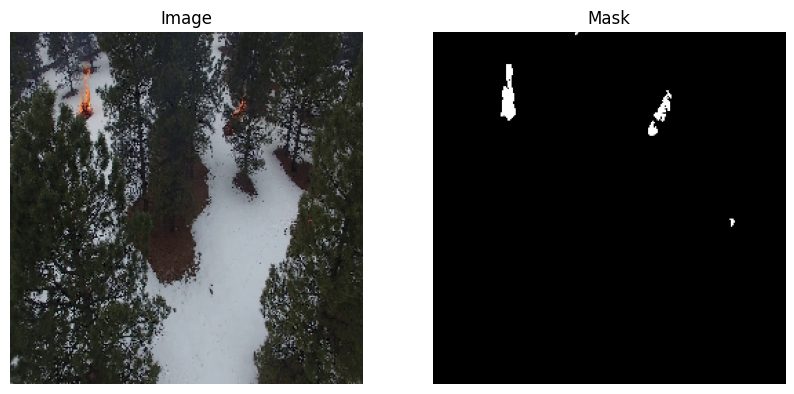

In [11]:
import matplotlib.pyplot as plt

for image, mask in Segmentation.take(1):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image[0].numpy().astype("uint8"))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask[0].numpy().squeeze(), cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.show()